In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [3]:
#LOAD DATASET

df = pd.read_csv("D:/ML Project/archive/Balanced_HR_Employee_Attrition.csv")

print("FIRST 5 ROWS")
pd.set_option('display.max_columns', None)
display(df.head())

# UNDERSTAND DATASET
print("DATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
print(df.info())

print("\nNULL VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
display(df.describe())

FIRST 5 ROWS


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,44,No,Travel_Rarely,136,Research & Development,28,3,Life Sciences,1,1523,4,Male,32,3,4,Research Director,1,Married,16328,22074,3,Y,No,13,3,3,80,1,24,1,4,20,6,14,17
1,35,Yes,Travel_Rarely,303,Sales,27,3,Life Sciences,1,1797,3,Male,84,3,2,Sales Executive,4,Single,5813,13492,1,Y,Yes,18,3,4,80,0,10,2,3,10,7,7,7
2,36,No,Travel_Rarely,928,Sales,1,2,Life Sciences,1,857,2,Male,56,3,2,Sales Executive,4,Married,6201,2823,1,Y,Yes,14,3,4,80,1,18,1,2,18,14,4,11
3,32,Yes,Travel_Rarely,414,Sales,2,4,Marketing,1,1862,3,Male,82,2,2,Sales Executive,2,Single,9907,26186,7,Y,Yes,12,3,3,80,0,7,3,2,2,2,2,2
4,19,Yes,Travel_Rarely,489,Human Resources,2,2,Technical Degree,1,566,1,Male,52,2,1,Human Resources,4,Single,2564,18437,1,Y,No,12,3,3,80,0,1,3,4,1,0,0,0


DATASET SHAPE
(2466, 35)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       2466 non-null   int64
 1   Attrition                 2466 non-null   str  
 2   BusinessTravel            2466 non-null   str  
 3   DailyRate                 2466 non-null   int64
 4   Department                2466 non-null   str  
 5   DistanceFromHome          2466 non-null   int64
 6   Education                 2466 non-null   int64
 7   EducationField            2466 non-null   str  
 8   EmployeeCount             2466 non-null   int64
 9   EmployeeNumber            2466 non-null   int64
 10  EnvironmentSatisfaction   2466 non-null   int64
 11  Gender                    2466 non-null   str  
 12  HourlyRate                2466 non-null   int64
 13  JobInvolvement            2466 non-null   int64
 14  JobLevel    

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,2466.000000,2466.000000,2466.000000,2466.000000,2466.0,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.0,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000
mean,35.640308,787.028792,9.607461,2.891322,1.0,1031.025142,2.612328,65.706813,2.635848,1.896594,2.637470,5822.551095,14277.482157,2.807380,15.189781,3.157340,2.662612,80.0,0.692214,10.049878,2.739254,2.731144,6.289943,3.686131,2.053933,3.609895
std,9.514161,404.301413,8.262921,1.009664,0.0,591.487340,1.138553,20.257621,0.753354,1.074248,1.117063,4430.834719,7156.089039,2.604062,3.719320,0.364195,1.086762,0.0,0.874101,7.812324,1.239862,0.740798,6.219178,3.531663,3.145674,3.476068
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,436.000000,2.000000,2.000000,1.0,508.500000,2.000000,48.000000,2.000000,1.000000,2.000000,2600.000000,8271.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,5.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000
50%,34.000000,756.000000,7.000000,3.000000,1.0,1038.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4379.000000,14255.000000,1.000000,14.000000,3.000000,3.000000,80.0,0.000000,8.000000,3.000000,3.000000,5.000000,2.000000,1.000000,2.000000
75%,42.000000,1141.000000,15.000000,4.000000,1.0,1544.750000,4.000000,84.000000,3.000000,2.000000,4.000000,7336.000000,20644.750000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,13.000000,3.000000,3.000000,9.000000,7.000000,2.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
#LABEL ENCODING

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

print("LABEL ENCODING COMPLETED")

LABEL ENCODING COMPLETED


C:\Users\hp\AppData\Local\Temp\ipykernel_330064\3410119969.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [5]:
#FIND CONSTANT & ID COLUMNS
constant_columns = []
id_like_columns = []

for col in df.columns:
    
    unique_values = df[col].nunique()
    
    # Constant columns
    if unique_values == 1:
        constant_columns.append(col)
    
    # Unique ID-like columns
    elif unique_values == len(df):
        id_like_columns.append(col)

print("Constant Columns :")
print(constant_columns)

print("\nUnique ID Columns :")
print(id_like_columns)

Constant Columns :
['EmployeeCount', 'Over18', 'StandardHours']

Unique ID Columns :
[]


In [6]:
#DROP CONSTANT & ID COLUMNS
drop_columns = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_columns, inplace=True)

print("Columns dropped successfully")

print("\nCurrent Shape :", df.shape)

Columns dropped successfully

Current Shape : (2466, 31)


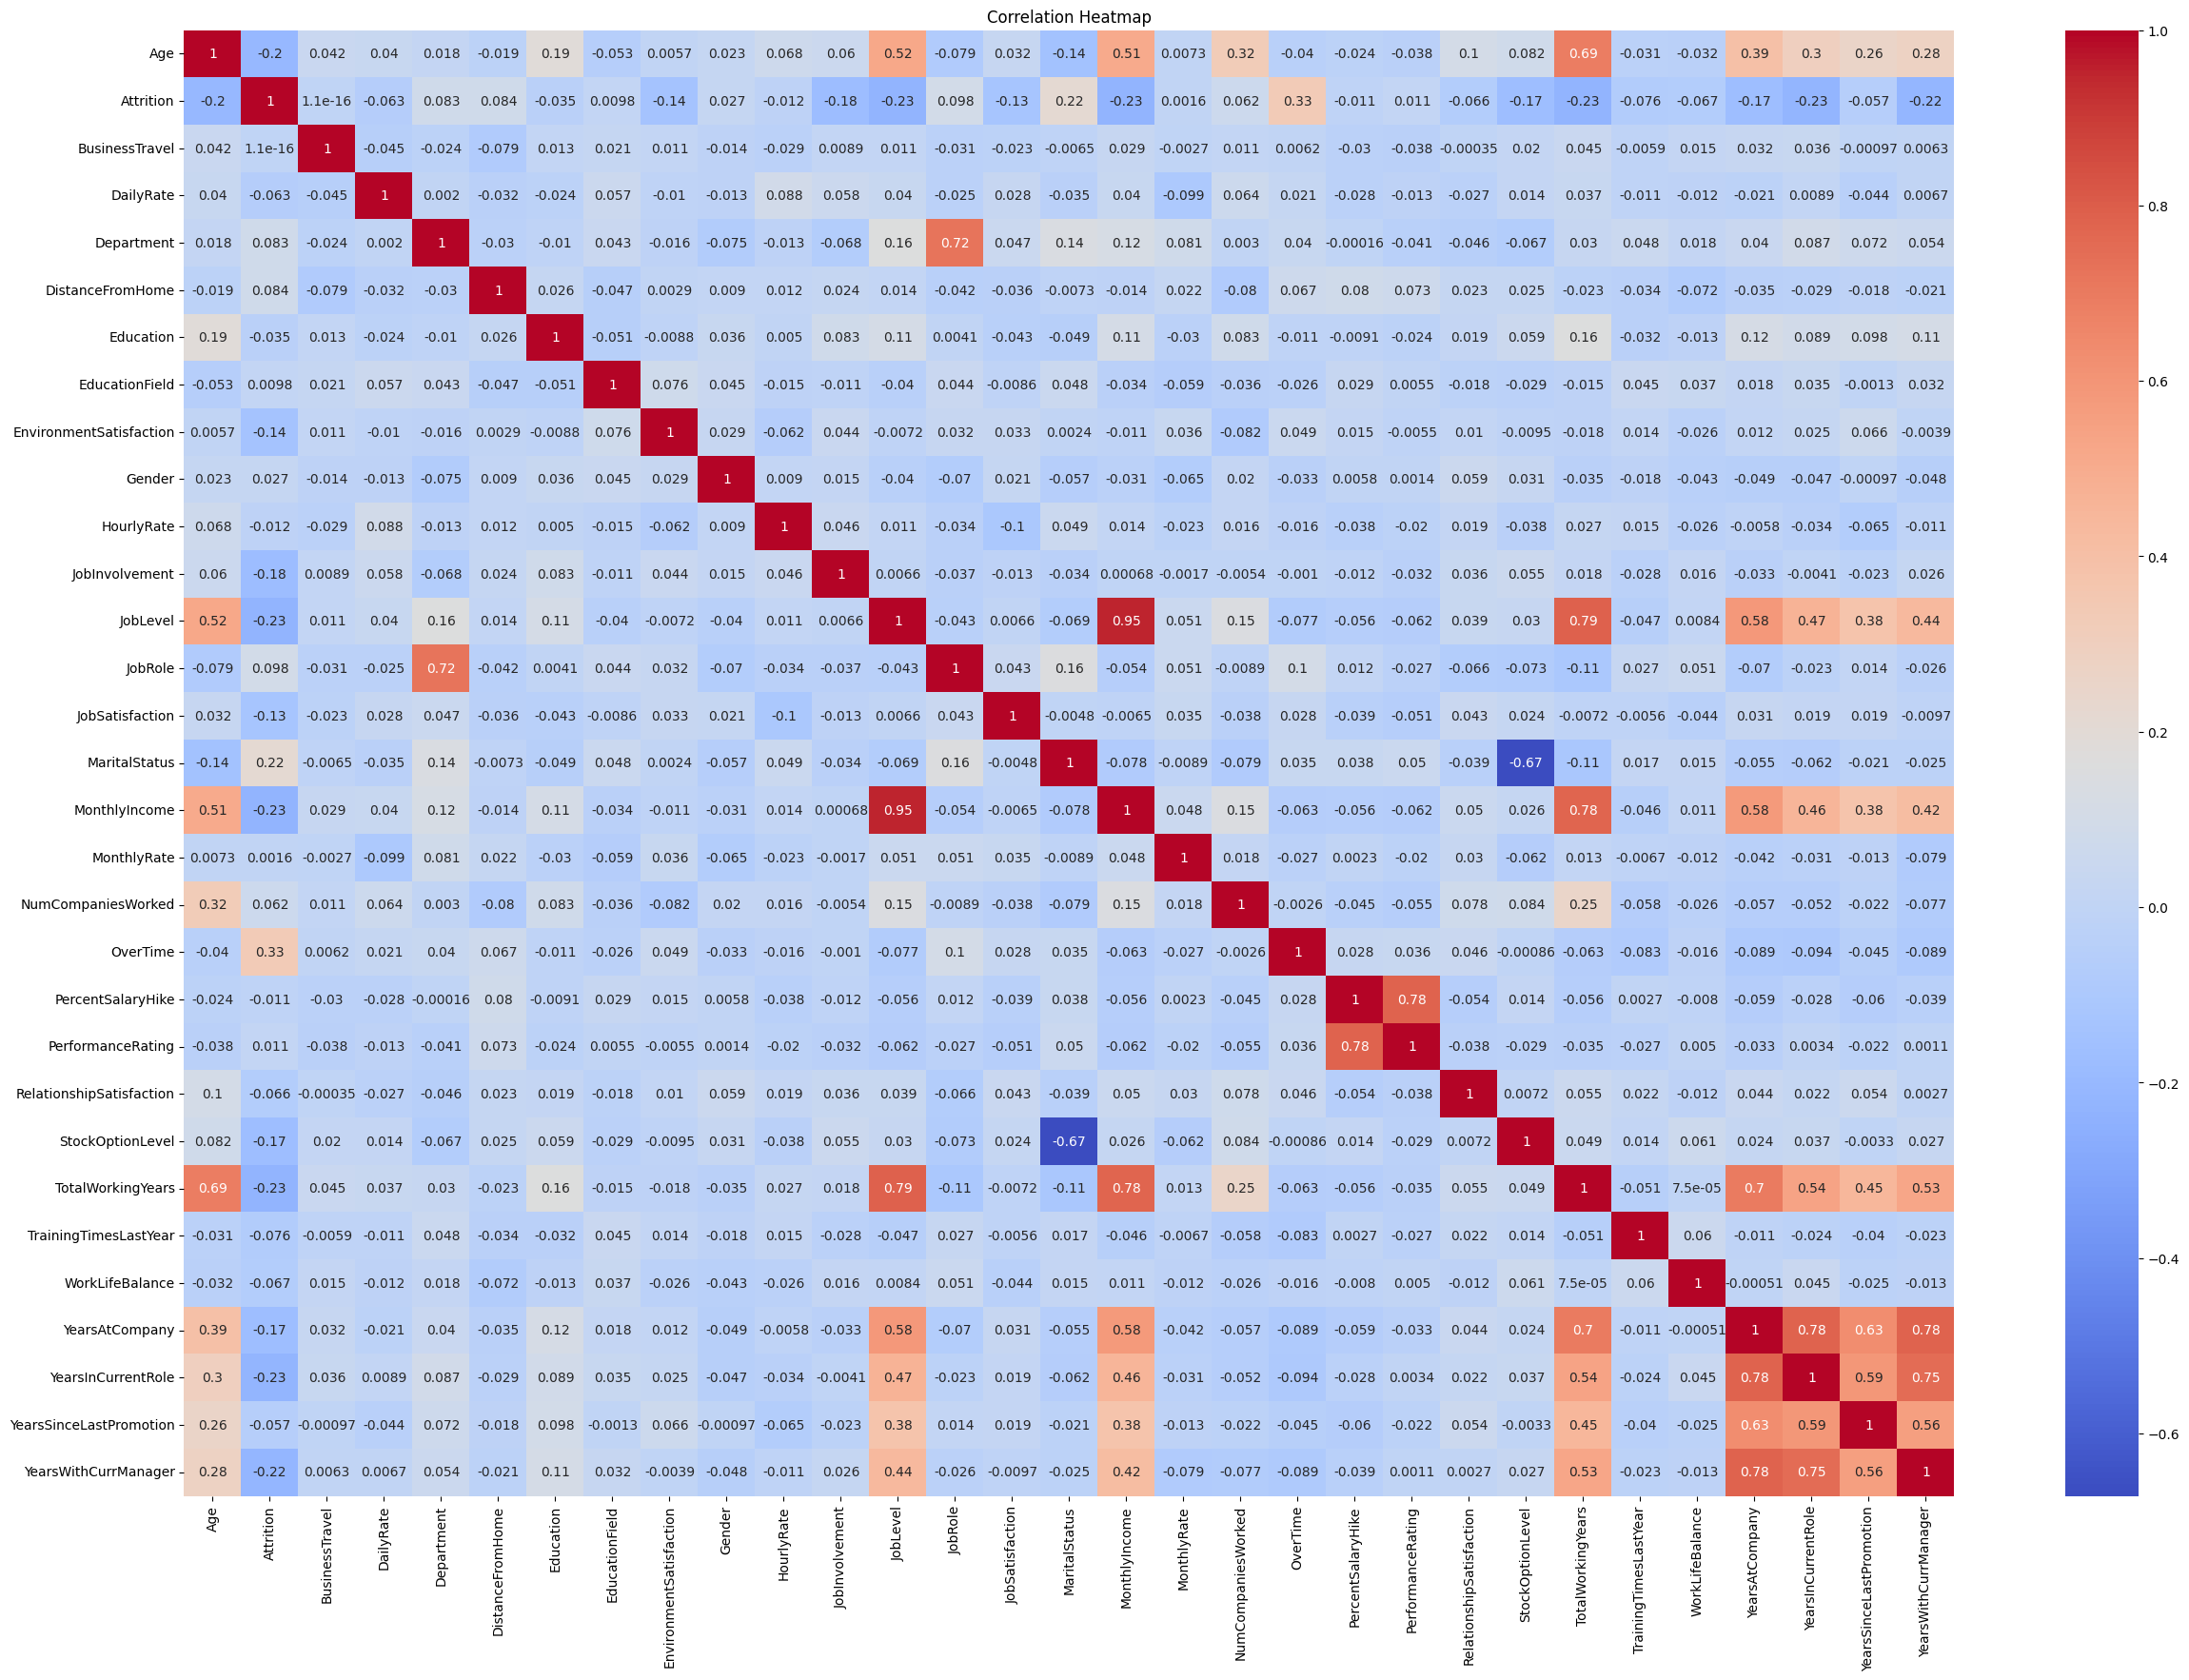

In [7]:
#HEATMAP
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
#FEATURE SELECTION,TRAIN TEST SPLIT & STANDARD SCALER
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X SHAPE :", X.shape)
print("Y SHAPE :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X SHAPE : (2466, 30)
Y SHAPE : (2466,)


In [9]:
#EVALUATION FUNCTION
results = []
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    
    results.append([name,accuracy,precision,recall,f1,roc])
    print(f"\n{name} RESULTS")
    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("ROC AUC :", roc)
    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression RESULTS
Accuracy : 0.7631578947368421
Precision : 0.7490196078431373
Recall : 0.7827868852459017
F1 Score : 0.7655310621242485
ROC AUC : 0.7633934426229508

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       250
           1       0.75      0.78      0.77       244

    accuracy                           0.76       494
   macro avg       0.76      0.76      0.76       494
weighted avg       0.76      0.76      0.76       494



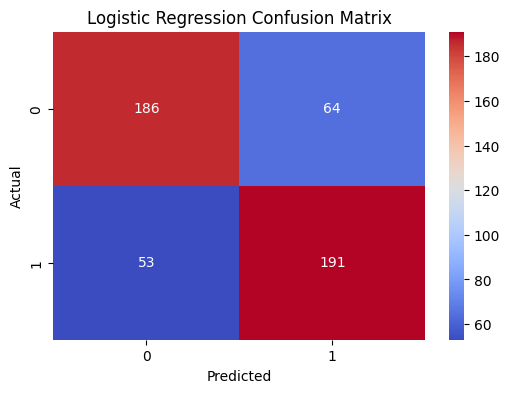

In [10]:
#LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Logistic Regression",y_test,y_pred_lr)


Random Forest RESULTS
Accuracy : 0.979757085020243
Precision : 0.9642857142857143
Recall : 0.9959016393442623
F1 Score : 0.9798387096774194
ROC AUC : 0.979950819672131

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       250
           1       0.96      1.00      0.98       244

    accuracy                           0.98       494
   macro avg       0.98      0.98      0.98       494
weighted avg       0.98      0.98      0.98       494



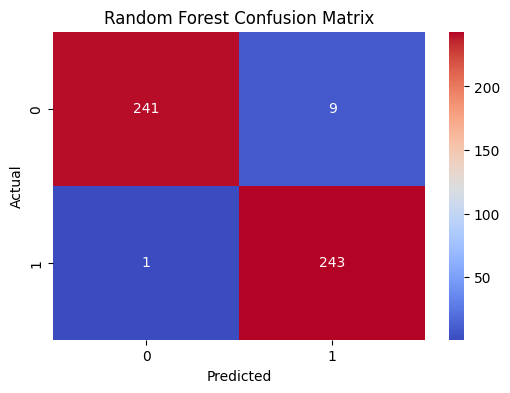

In [11]:
#RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model("Random Forest",y_test,y_pred_rf)


CART Decision Tree RESULTS
Accuracy : 0.7246963562753036
Precision : 0.7454545454545455
Recall : 0.6721311475409836
F1 Score : 0.7068965517241379
ROC AUC : 0.7240655737704919

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       250
           1       0.75      0.67      0.71       244

    accuracy                           0.72       494
   macro avg       0.73      0.72      0.72       494
weighted avg       0.73      0.72      0.72       494



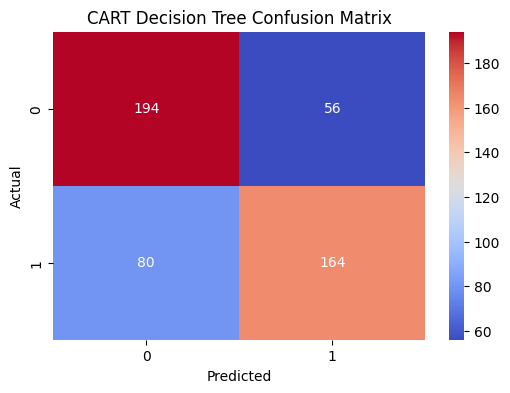

In [12]:
#CART DECISION TREE
dt = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
evaluate_model("CART Decision Tree",y_test,y_pred_dt)


KNN RESULTS
Accuracy : 0.8279352226720648
Precision : 0.7694915254237288
Recall : 0.930327868852459
F1 Score : 0.8423005565862709
ROC AUC : 0.8291639344262295

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       250
           1       0.77      0.93      0.84       244

    accuracy                           0.83       494
   macro avg       0.84      0.83      0.83       494
weighted avg       0.84      0.83      0.83       494



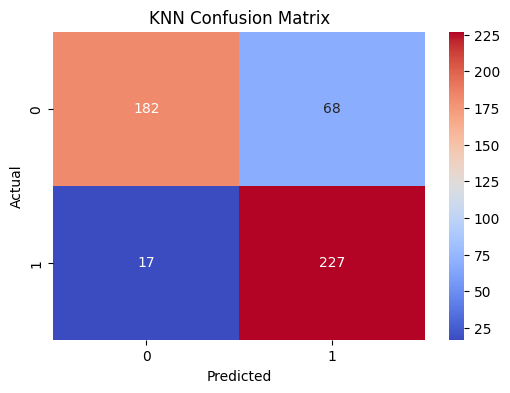

In [13]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model("KNN",y_test,y_pred_knn)

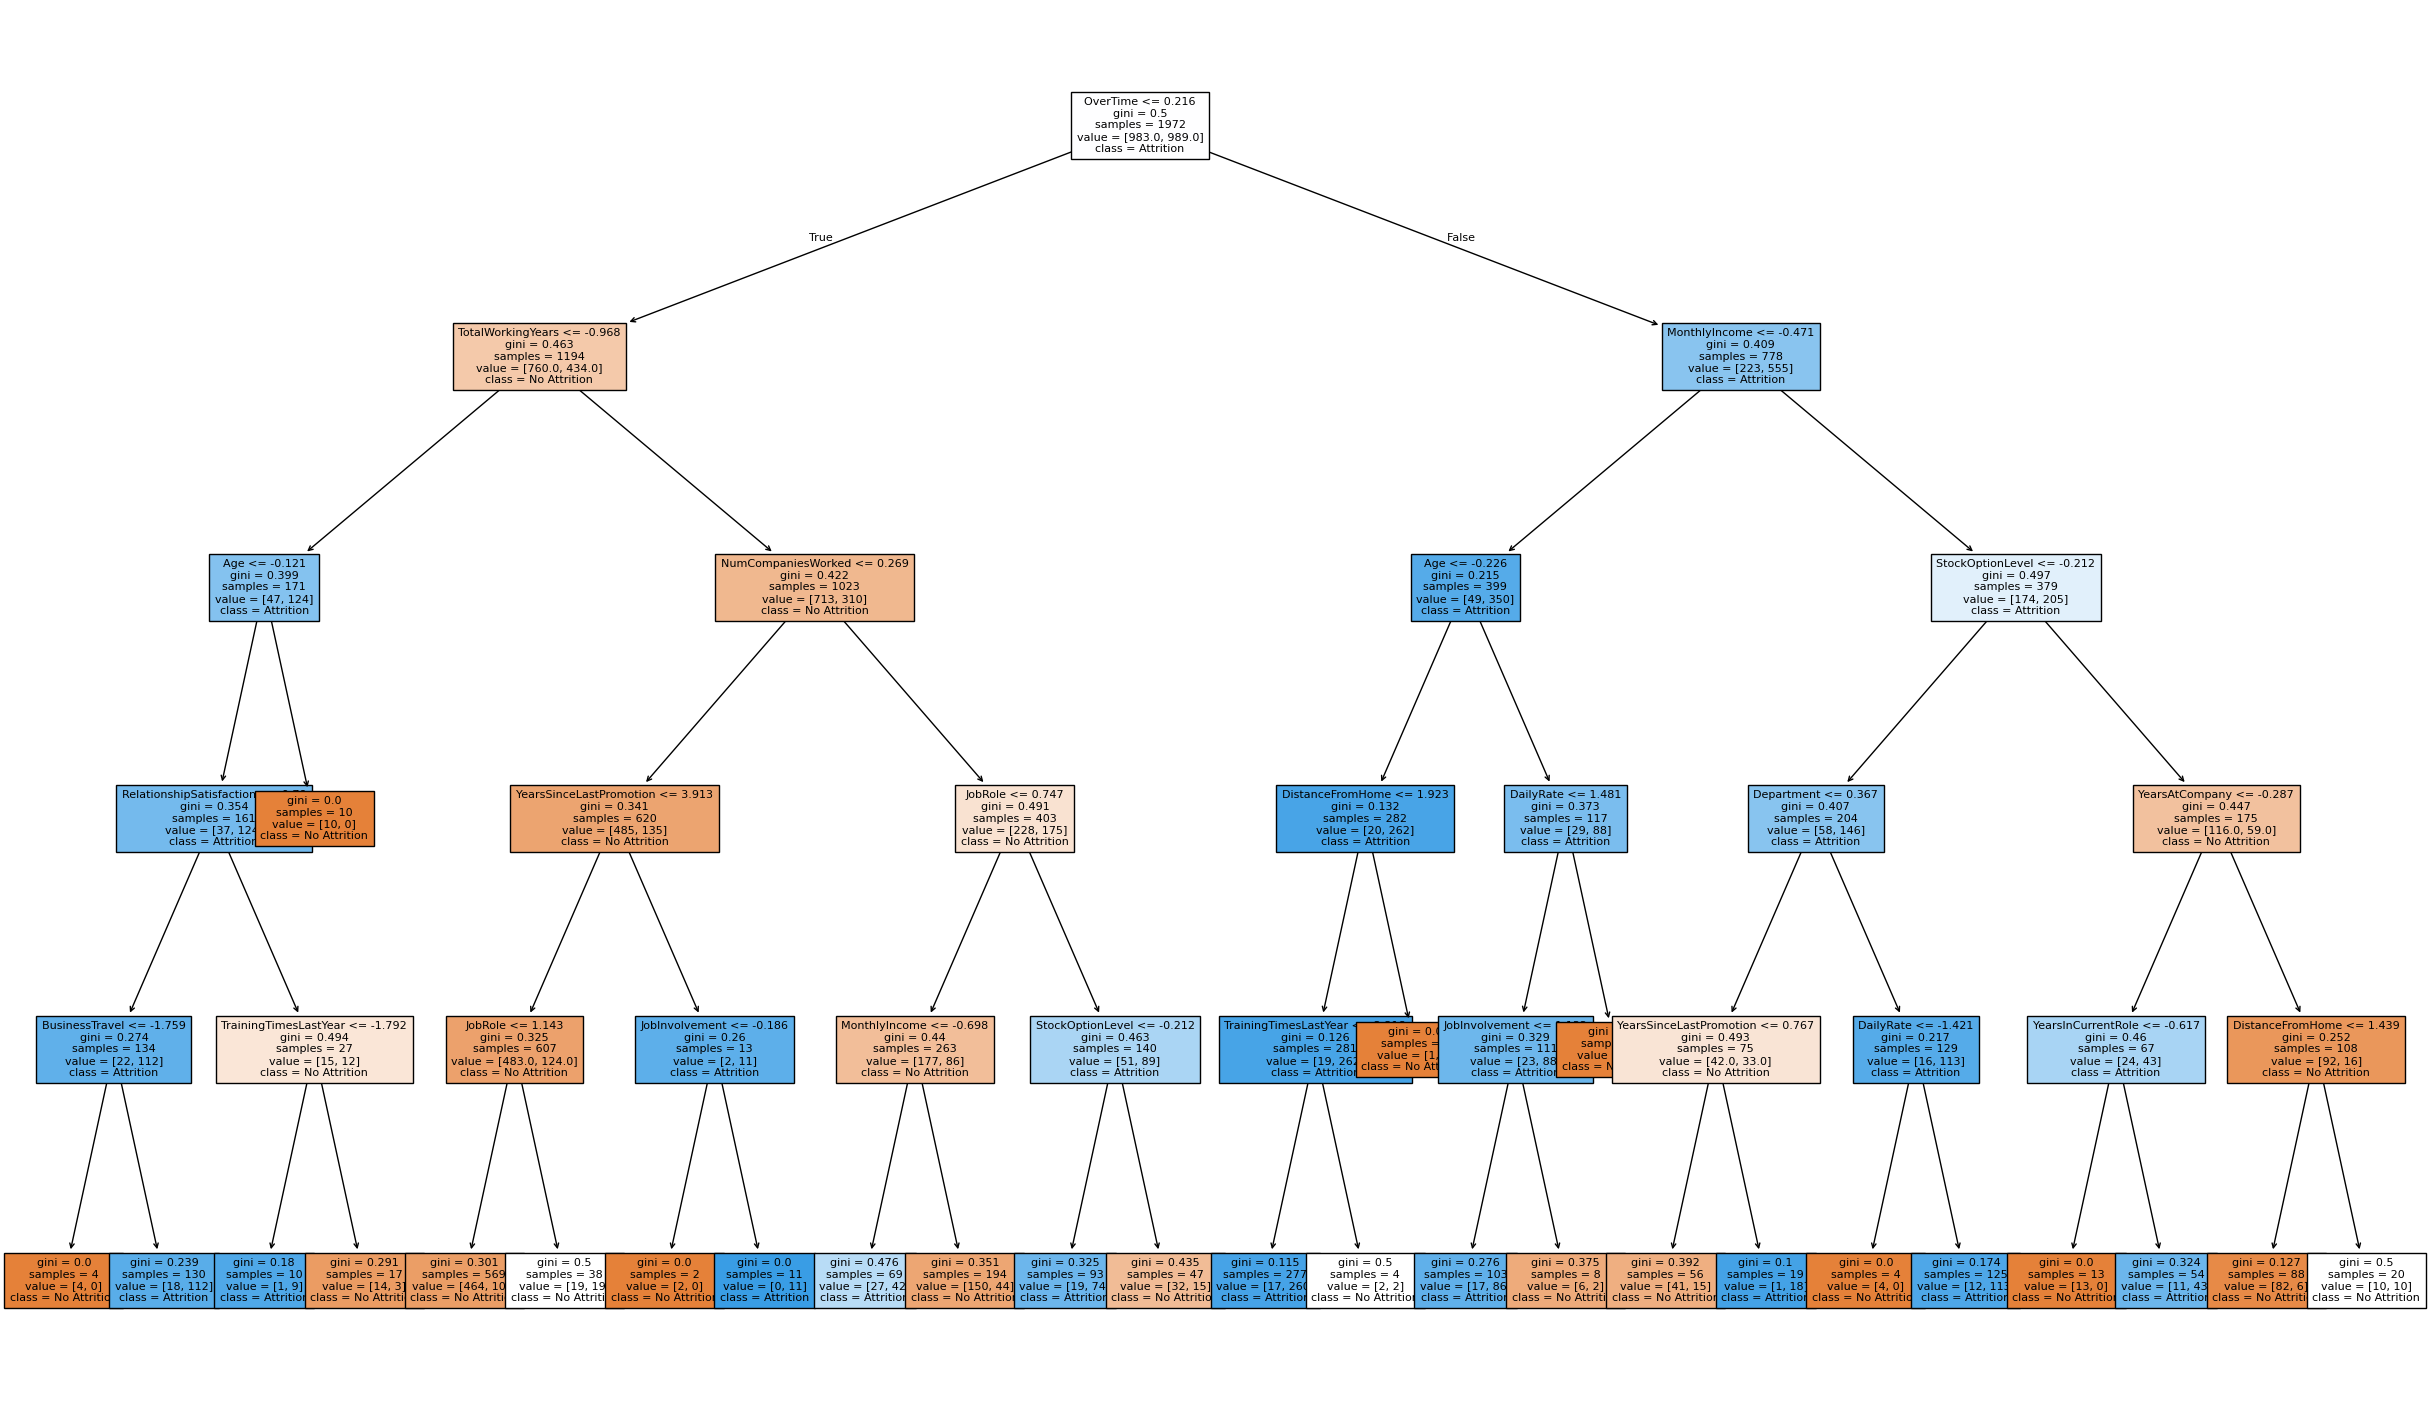

In [14]:
# DECISION TREE PLOT
plt.figure(figsize=(31,18))
plot_tree(dt,feature_names=X.columns,class_names=['No Attrition', 'Attrition'],filled=True,fontsize=8)
plt.show()

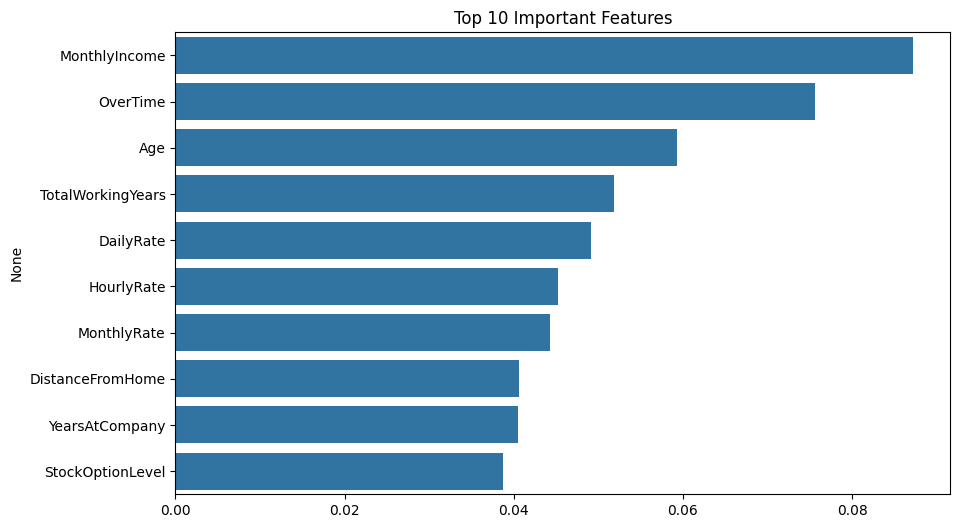

In [15]:
#RANDOM FOREST FEATURE IMPORTANCE
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values[:10],y=importance.index[:10])
plt.title("Top 10 Important Features")
plt.show()

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.763158,0.749020,0.782787,0.765531,0.763393
1,Random Forest,0.979757,0.964286,0.995902,0.979839,0.979951
2,CART Decision Tree,0.724696,0.745455,0.672131,0.706897,0.724066
3,KNN,0.827935,0.769492,0.930328,0.842301,0.829164


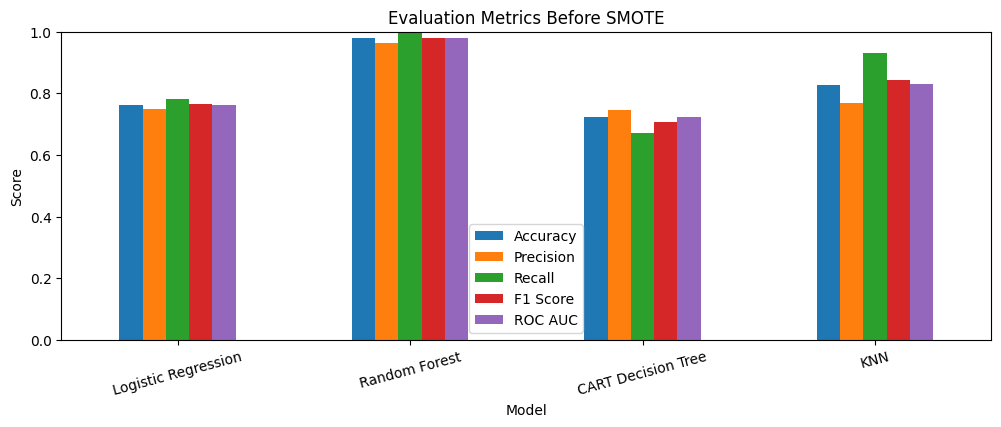

In [16]:
#COMPARISON TABLE
results_df = pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(results_df)

#METRICS GRAPH
metrics_df = results_df.set_index("Model")
metrics_df.plot(kind='bar',figsize=(12,4))
plt.title("Evaluation Metrics Before SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [17]:
#APPLY SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled,y_train)
print("Before SMOTE")
print(y_train.value_counts())
print("\nAfter SMOTE")
print(pd.Series(y_smote).value_counts())

Before SMOTE
Attrition
1    989
0    983
Name: count, dtype: int64

After SMOTE
Attrition
1    989
0    989
Name: count, dtype: int64


In [18]:
#TRAIN MODELS AFTER SMOTE
smote_results = []
def evaluate_smote_model(name, y_test, y_pred):
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    smote_results.append([name,accuracy,precision,recall,f1,roc])
    
# Logistic Regression
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_smote, y_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
evaluate_smote_model("LR + SMOTE",y_test,y_pred_lr_smote
                    )
# Random Forest
rf_smote = RandomForestClassifier(n_estimators=100,random_state=42)
rf_smote.fit(X_smote, y_smote)
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
evaluate_smote_model("RF + SMOTE",y_test,y_pred_rf_smote)

# CART
dt_smote = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
dt_smote.fit(X_smote, y_smote)
y_pred_dt_smote = dt_smote.predict(X_test_scaled)
evaluate_smote_model("DT + SMOTE",y_test,y_pred_dt_smote)

# KNN
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_smote, y_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)
evaluate_smote_model("KNN + SMOTE",y_test,y_pred_knn_smote)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LR + SMOTE,0.763158,0.749020,0.782787,0.765531,0.763393
1,RF + SMOTE,0.975709,0.956693,0.995902,0.975904,0.975951
2,DT + SMOTE,0.732794,0.754545,0.680328,0.715517,0.732164
3,KNN + SMOTE,0.827935,0.769492,0.930328,0.842301,0.829164


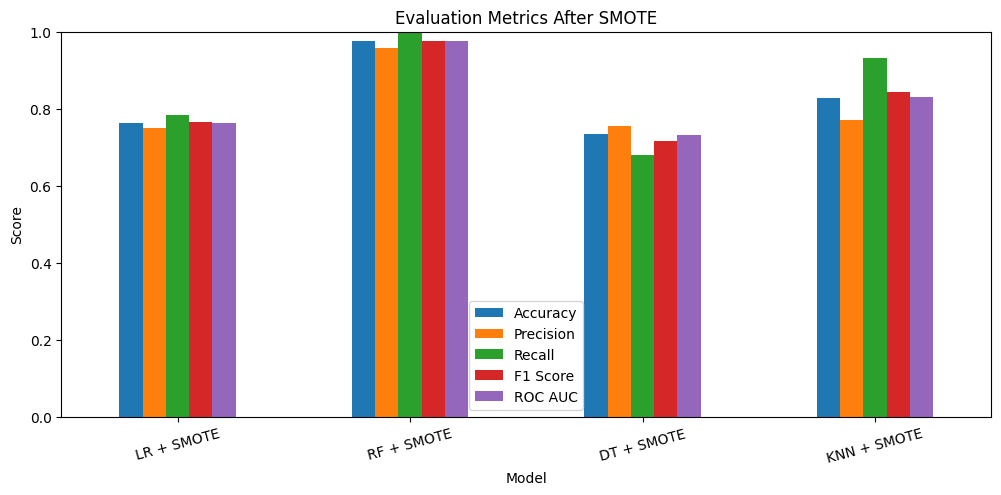

In [19]:
#SMOTE COMPARISON TABLE
smote_results_df = pd.DataFrame(smote_results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(smote_results_df)

#AFTER SMOTE METRICS GRAPH
smote_metrics_df = smote_results_df.set_index("Model")
smote_metrics_df.plot(kind='bar',figsize=(12,5))
plt.title("Evaluation Metrics After SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

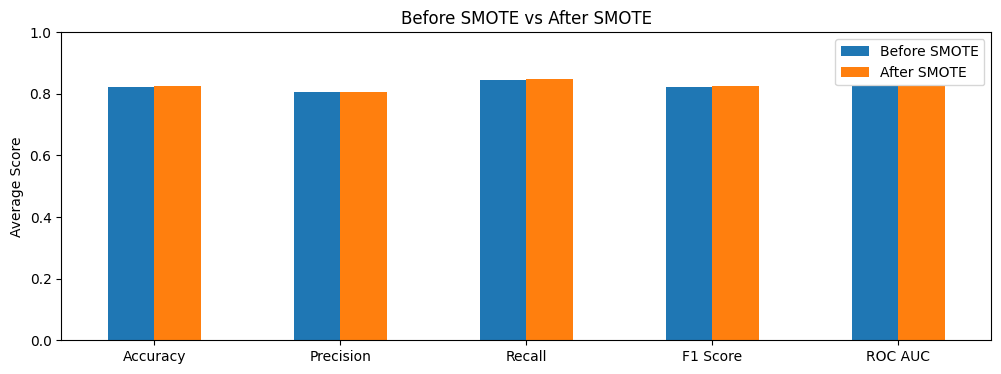

In [20]:
#BEFORE VS AFTER SMOTE COMPARISON
before_smote_avg = results_df.drop("Model", axis=1).mean()
after_smote_avg = smote_results_df.drop("Model", axis=1).mean()
comparison_df = pd.DataFrame({"Before SMOTE": before_smote_avg,"After SMOTE": after_smote_avg})
comparison_df.plot(kind='bar',figsize=(12,4))
plt.title("Before SMOTE vs After SMOTE")
plt.ylabel("Average Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend()
plt.show()